## Importing, Cleaning, Minor Feature Engineering 

In [30]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.ticker as mtick
plt.isinteractive = True
warnings.filterwarnings('ignore')

In [31]:
df =pd.read_csv('data/amazon.csv')

In [32]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [33]:
df['discounted_price'] = df['discounted_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹','', regex = False).str.replace(',','', regex = False).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%','', regex =False).astype(float)
df['rating'] = df['rating'].str.replace('|','0', regex = False).astype(float)
df['rating_count'] = df['rating_count'].str.replace(',','', regex = False).astype(float)


In [34]:
df['main_category'] = df['category'].str.split('|').str[0]
df['sub_category'] = df['category'].str.split('|').str[1]
col = ['category', 'product_id', 'product_name','about_product','user_id', 'user_name', 'review_id', 'review_content','img_link','product_link']
df.drop(col, axis = 1, inplace = True)
df.head()


,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,main_category,sub_category
0,399.0,1099.0,64.0,4.2,24269.0,"Satisfied,Charging is really fast,Value for mo...",Computers&Accessories,Accessories&Peripherals
1,199.0,349.0,43.0,4.0,43994.0,"A Good Braided Cable for Your Type C Device,Go...",Computers&Accessories,Accessories&Peripherals
2,199.0,1899.0,90.0,3.9,7928.0,"Good speed for earlier versions,Good Product,W...",Computers&Accessories,Accessories&Peripherals
3,329.0,699.0,53.0,4.2,94363.0,"Good product,Good one,Nice,Really nice product...",Computers&Accessories,Accessories&Peripherals
4,154.0,399.0,61.0,4.2,16905.0,"As good as original,Decent,Good one for second...",Computers&Accessories,Accessories&Peripherals


In [35]:
# df['estimated_sales'] = df['rating_count']*50
# df['estimated_revenue_discount'] = df['estimated_sales']*df['discounted_price']
# df['estimated_revenue_actual'] = df['estimated_sales']*df['actual_price']

## Univariate Analysis

### Numerical

In [36]:
df['discounted_price'].describe()

count     1465.000000
mean      3125.310874
std       6944.304394
min         39.000000
25%        325.000000
50%        799.000000
75%       1999.000000
max      77990.000000
Name: discounted_price, dtype: float64

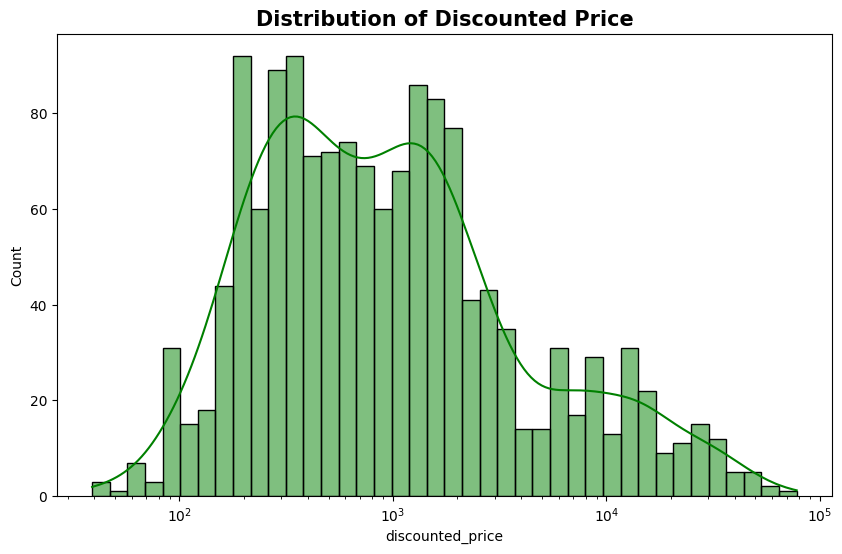

In [37]:
plt.figure(figsize =(10,6))
sns.histplot(x=df['discounted_price'], bins = 40,color = 'green', kde = True, log_scale = True)
plt.title('Distribution of Discounted Price',fontsize  = 15, fontweight = 'bold')
plt.show()

In [38]:
df['actual_price'].describe()

count      1465.000000
mean       5444.990635
std       10874.826864
min          39.000000
25%         800.000000
50%        1650.000000
75%        4295.000000
max      139900.000000
Name: actual_price, dtype: float64

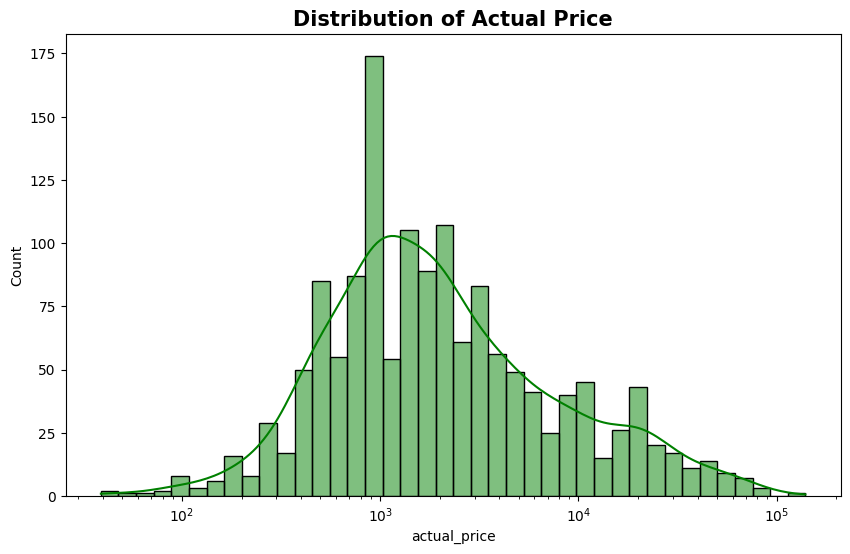

In [39]:
plt.figure(figsize =(10,6))
sns.histplot(x=df['actual_price'], bins = 40,color = 'green', kde = True, log_scale = True)
plt.title('Distribution of Actual Price', fontsize  = 15, fontweight = 'bold')
plt.show()

In [40]:
df['discount_percentage'].describe()

count    1465.000000
mean       47.691468
std        21.635905
min         0.000000
25%        32.000000
50%        50.000000
75%        63.000000
max        94.000000
Name: discount_percentage, dtype: float64

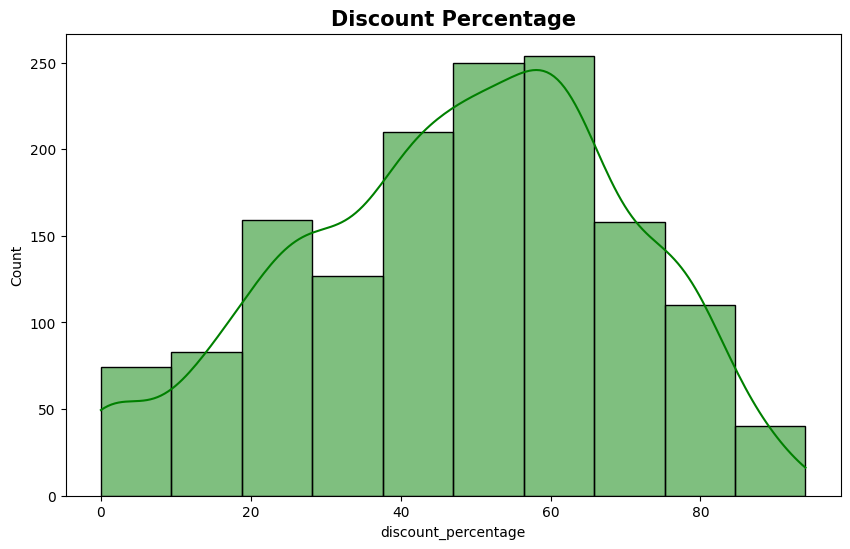

In [41]:
plt.figure(figsize =(10,6))
sns.histplot(x=df['discount_percentage'], bins = 10,color = 'green', kde = True, )
plt.title('Discount Percentage', fontsize  = 15, fontweight = 'bold')
plt.show()

In [42]:
df['rating'].describe()

count    1465.000000
mean        4.093788
std         0.310598
min         0.000000
25%         4.000000
50%         4.100000
75%         4.300000
max         5.000000
Name: rating, dtype: float64

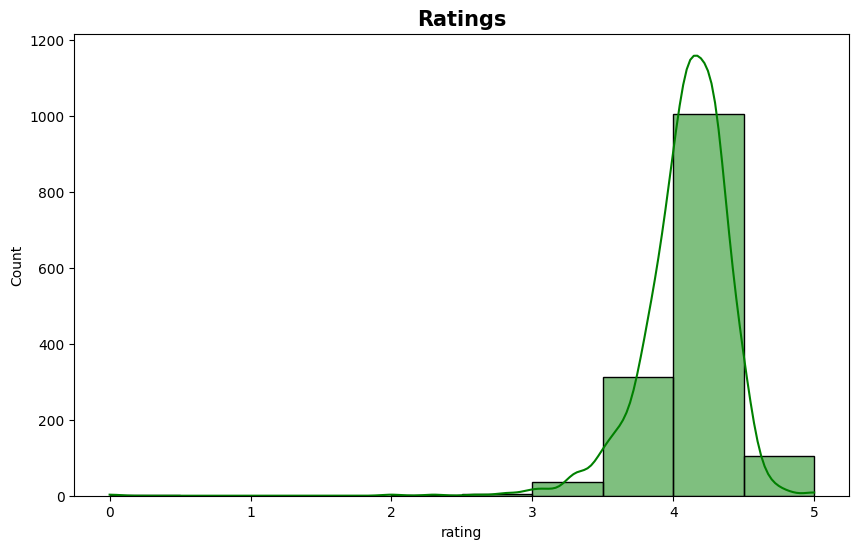

In [43]:
plt.figure(figsize =(10,6))
sns.histplot(x=df['rating'], bins = 10,color = 'green', kde = True, )
plt.title('Ratings', fontsize  = 15, fontweight = 'bold')
plt.show()

In [44]:
df['rating_count'].describe()

count      1463.000000
mean      18295.541353
std       42753.864952
min           2.000000
25%        1186.000000
50%        5179.000000
75%       17336.500000
max      426973.000000
Name: rating_count, dtype: float64

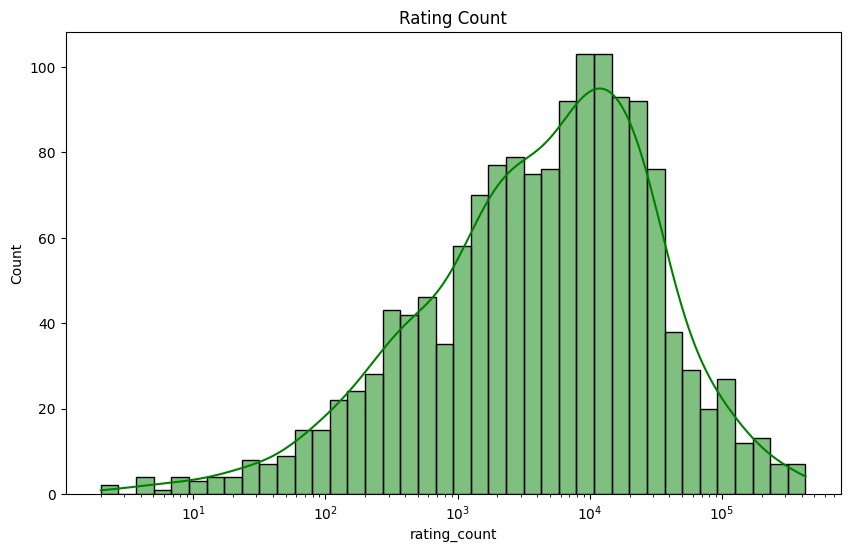

In [45]:
plt.figure(figsize =(10,6))
sns.histplot(x=df['rating_count'], bins = 40,color = 'green', kde = True, log_scale = True)
plt.title('Rating Count')
plt.show()

In [46]:
df.head()

,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,main_category,sub_category
0,399.0,1099.0,64.0,4.2,24269.0,"Satisfied,Charging is really fast,Value for mo...",Computers&Accessories,Accessories&Peripherals
1,199.0,349.0,43.0,4.0,43994.0,"A Good Braided Cable for Your Type C Device,Go...",Computers&Accessories,Accessories&Peripherals
2,199.0,1899.0,90.0,3.9,7928.0,"Good speed for earlier versions,Good Product,W...",Computers&Accessories,Accessories&Peripherals
3,329.0,699.0,53.0,4.2,94363.0,"Good product,Good one,Nice,Really nice product...",Computers&Accessories,Accessories&Peripherals
4,154.0,399.0,61.0,4.2,16905.0,"As good as original,Decent,Good one for second...",Computers&Accessories,Accessories&Peripherals


In [47]:
df['main_category'].unique()

array(['Computers&Accessories', 'Electronics', 'MusicalInstruments',
       'OfficeProducts', 'Home&Kitchen', 'HomeImprovement', 'Toys&Games',
       'Car&Motorbike', 'Health&PersonalCare'], dtype=object)

### Categorical

Text(-58.277777777777786, 0.5, 'category')

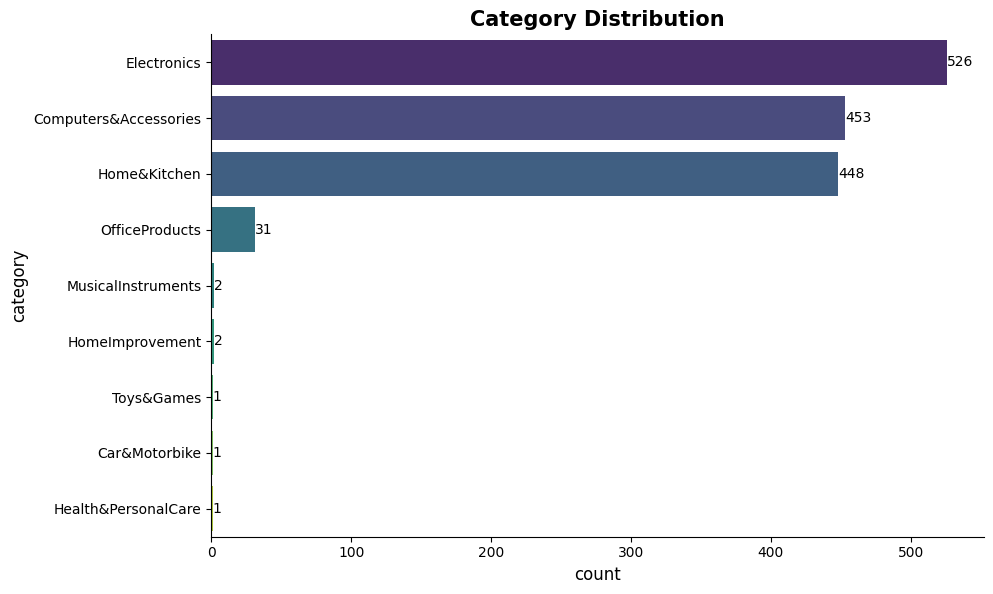

In [48]:
plt.figure(figsize = (10,6))
ax = sns.countplot(data = df, y = 'main_category', order = df['main_category'].value_counts().index, palette = 'viridis',)
plt.title('Category Distribution', fontsize = 15, fontweight = 'bold')
# plt.xticks(rotation = 45)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
sns.despine()
plt.xlabel('count', fontsize = 12)
plt.ylabel('category', fontsize = 12)

Text(-189.02777777777777, 0.5, 'Sub-Category')

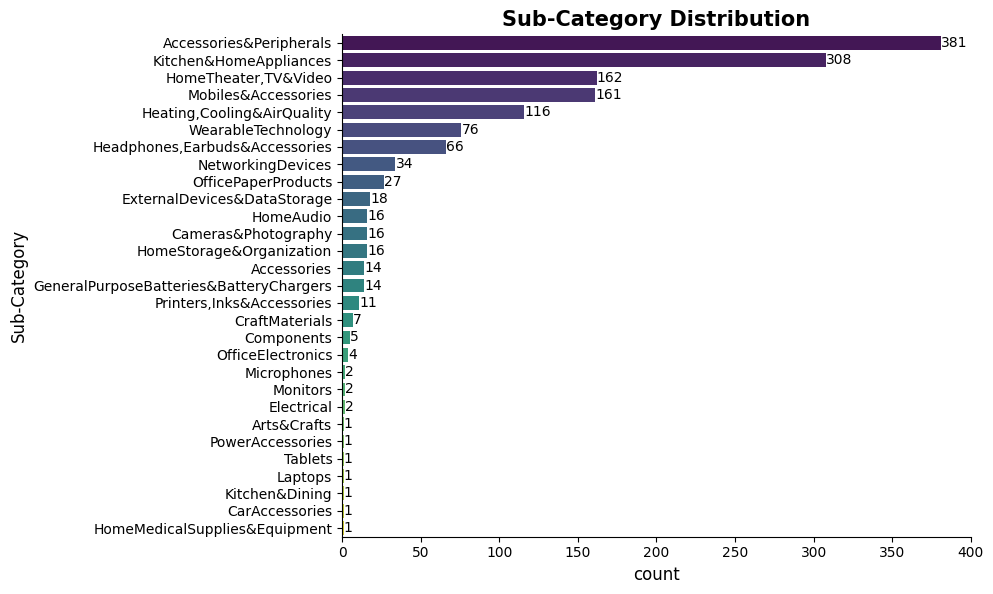

In [49]:
plt.figure(figsize = (10,6))
ax = sns.countplot(data = df, y = 'sub_category', order = df['sub_category'].value_counts().index, palette = 'viridis',)
plt.title('Sub-Category Distribution', fontsize = 15, fontweight = 'bold')
# plt.xticks(rotation = 45)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
sns.despine()
plt.xlabel('count', fontsize = 12)
plt.ylabel('Sub-Category', fontsize = 12)

## Bivariate + Multivariate Analysis


### Numerical vs Numerical

Text(0, 0.5, 'Rating')

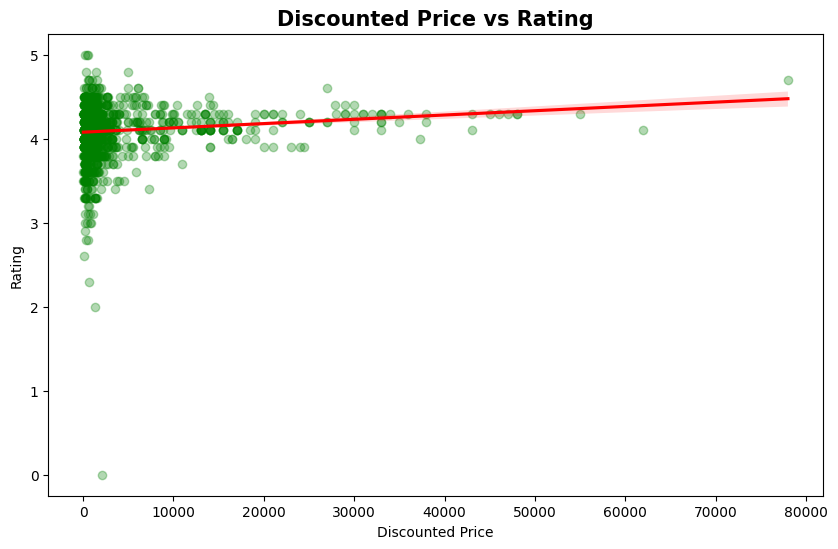

In [50]:
plt.figure(figsize = (10,6))
sns.regplot(data = df,
            x= 'discounted_price',
            y= 'rating',scatter_kws = {'alpha':0.3, 'color':'green'}, line_kws = {'color':'red'})
plt.title('Discounted Price vs Rating', fontsize = 15, fontweight = 'bold')
plt.xlabel('Discounted Price')
plt.ylabel('Rating')


Text(0, 0.5, 'Rating')

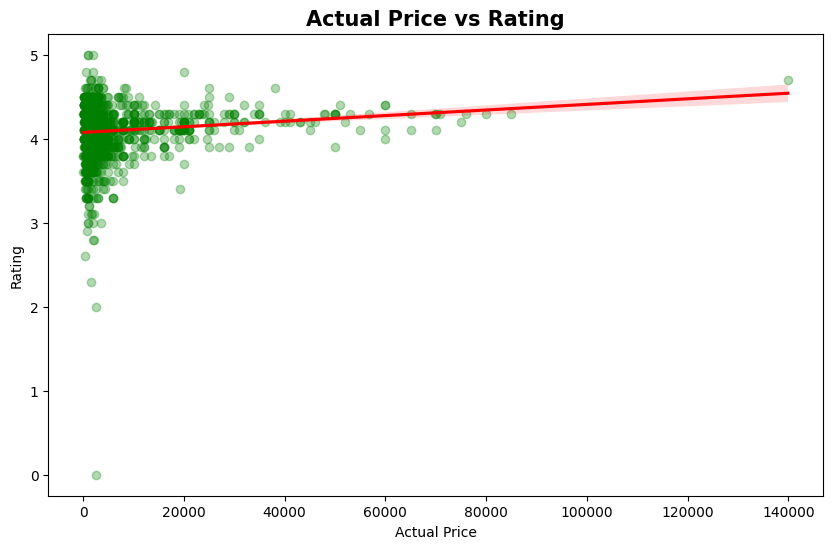

In [51]:
plt.figure(figsize = (10,6))
sns.regplot(data = df,
            x= 'actual_price',
            y= 'rating',scatter_kws = {'alpha':0.3, 'color':'green'}, line_kws = {'color':'red'})
plt.title('Actual Price vs Rating', fontsize = 15, fontweight = 'bold')
plt.xlabel('Actual Price')
plt.ylabel('Rating')


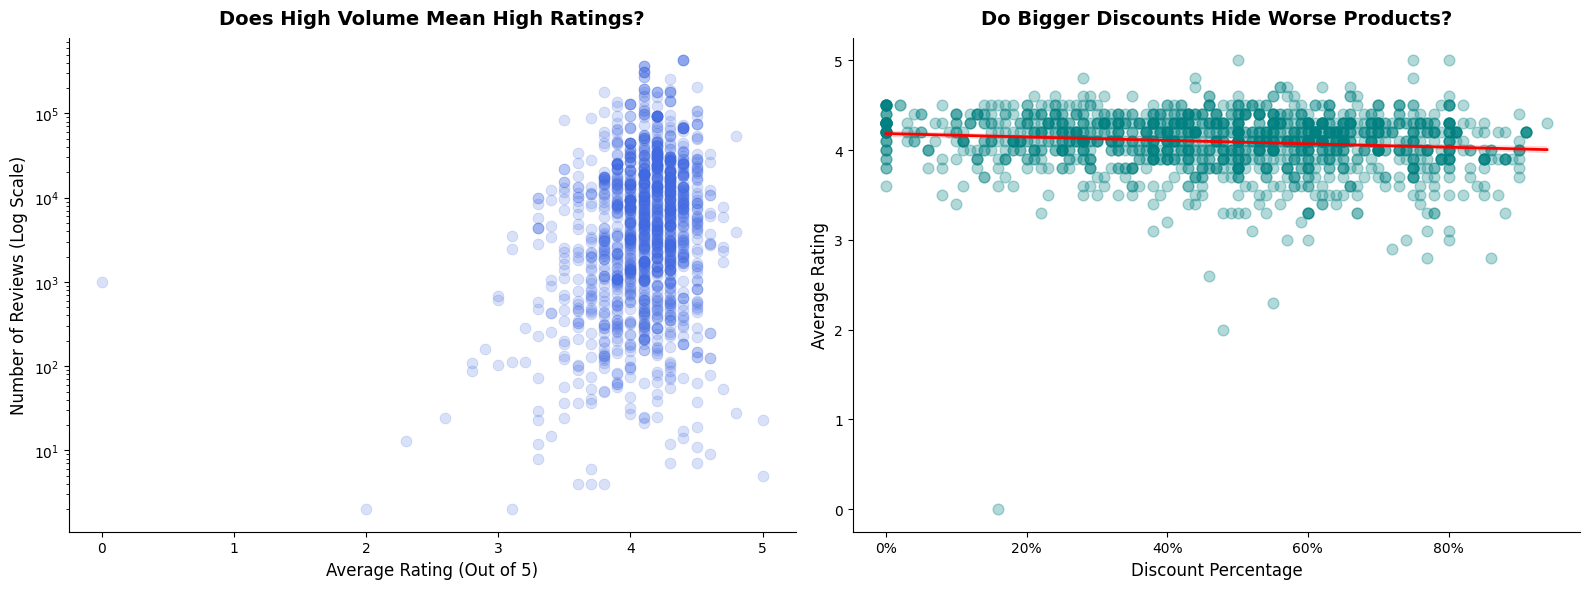

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# --- 1. CRITICAL FIX: Clean the discount_percentage column ---
# We must strip the '%' and ',' symbols and convert to decimal, otherwise regplot fails!
if df['discount_percentage'].dtype == 'object':
    df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%', '', regex=False).str.replace(',', '', regex=False).astype(float) / 100

# --- 2. Set up the 1x2 Dashboard ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 3. CHART 1: Rating vs. Rating Count (Fixing the Blue Wall) ---
sns.scatterplot(
    x='rating', 
    y='rating_count', 
    data=df, 
    ax=axes[0], 
    color='royalblue', 
    alpha=0.2,       # FIX: Lowered transparency so dense clusters look like clouds, not a solid wall
    s=60,            # FIX: Shrunk the dot size to prevent overlapping
    edgecolor=None   
)

axes[0].set_yscale('log') # Keep the log scale for viral products
axes[0].set_title('Does High Volume Mean High Ratings?', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Average Rating (Out of 5)', fontsize=12)
axes[0].set_ylabel('Number of Reviews (Log Scale)', fontsize=12)

# --- 4. CHART 2: Discount Percentage vs. Rating ---
sns.regplot(
    x='discount_percentage', 
    y='rating', 
    data=df, 
    ax=axes[1], 
    scatter_kws={'alpha': 0.3, 's': 60 ,'color': 'teal', 'edgecolor': None}, 
    line_kws={'color': 'red', 'linewidth': 2, }
    
)

axes[1].set_title('Do Bigger Discounts Hide Worse Products?', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Discount Percentage', fontsize=12)
axes[1].set_ylabel('Average Rating', fontsize=12)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(100))

# --- 5. Clean up and Display ---
sns.despine()
plt.tight_layout()
plt.show()

### Categorical vs Categorical 

In [53]:
# You may need to run this in your terminal first: pip install plotly
import pandas as pd
import plotly.express as px

# ==========================================
# 1. PREPARE THE HIERARCHICAL DATA
# ==========================================
# We group by BOTH categories to count exactly how many items exist in each specific combination
hierarchy_counts = df.groupby(['main_category', 'sub_category']).size().reset_index(name='count')

# ==========================================
# 2. FILTERING (To prevent browser lag)
# ==========================================
# Find the Top 5 Main Categories
top_mains = df['main_category'].value_counts().nlargest(5).index

# Keep only the rows that belong to those Top 5 Main Categories
hierarchy_filtered = hierarchy_counts[hierarchy_counts['main_category'].isin(top_mains)]

# The Magic Trick: Keep only the Top 10 Subcategories WITHIN each Main Category
hierarchy_final = (hierarchy_filtered
                   .sort_values(['main_category', 'count'], ascending=[True, False])
                   .groupby('main_category')
                   .head(10))

# ==========================================
# 3. BUILD THE INTERACTIVE TREEMAP
# ==========================================
fig = px.treemap(
    hierarchy_final,
    path=['main_category', 'sub_category'], # <--- This tells Plotly who is the Parent and who is the Child!
    values='count',                        # Box size is based on item count
    color='main_category',                 # Color-code by the parent category
    title='Amazon Product Hierarchy: Main Category vs. Subcategory',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# Make the labels clear and readable
fig.update_traces(textinfo='label+value+percent parent')
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))

# This will open a fully interactive HTML chart in your browser or notebook!
fig.show()

### Numerical vs Categorical

In [54]:
# Filter the top 5 categories for further analysis
top_5_cats = df['main_category'].value_counts().nlargest(5).index
df_top5 = df[df['main_category'].isin(top_5_cats)]

#================================= 
#      PLOTLY EXPRESSION
#=================================
fig = px.violin(df_top5, x = 'main_category', y = 'rating', color = 'main_category', box = True, points = 'all', hover_data=['sub_category'],
                title = 'Distribution of Ratings across Top 5 Categories',
                labels = {'main_category': 'Product_Category','rating': 'Product Rating(Out of 5)'},
                template = 'plotly_white')
#=======================
#      FINE TUNING
#=======================
fig.update_layout(showlegend = False, 
                  xaxis = {'categoryorder': 'total descending'},
                  title_font=dict(size = 16, family = 'Arial', weight = 'bold'))
fig.show()

In [55]:
# Filter the top 5 from sample of 1000
df_sample = df.sample(1000, random_state = 42)
top_5_cats = df_sample['main_category'].value_counts().nlargest(5).index
df_3d = df_sample[df_sample['main_category'].isin(top_5_cats)]

#=================================
#      PLOTLY 3D ENGINE
#=================================

fig = px.scatter_3d(df_3d, x = 'actual_price', y = 'discount_percentage', z = 'rating', color = 'main_category',
                    hover_data = ['sub_category'],
                    title = '4D Analysis: Price vs Discount vs Rating by Category',
                    opacity = 0.7,
                    color_discrete_sequence = px.colors.qualitative.Set2)
#=======================
#      FINE TUNING
#=======================
fig.update_traces(marker = dict(size = 4))
fig.update_layout(
    template = 'plotly_dark',
    margin = dict(l = 0, r = 0, b = 0, t = 50),
    scene = dict(
        xaxis_title = 'Actual Price(₹)',
        yaxis_title = 'Discount Percentage(%)',
        zaxis_title = 'Rating(Out of 5)'
    )
)
fig.show()

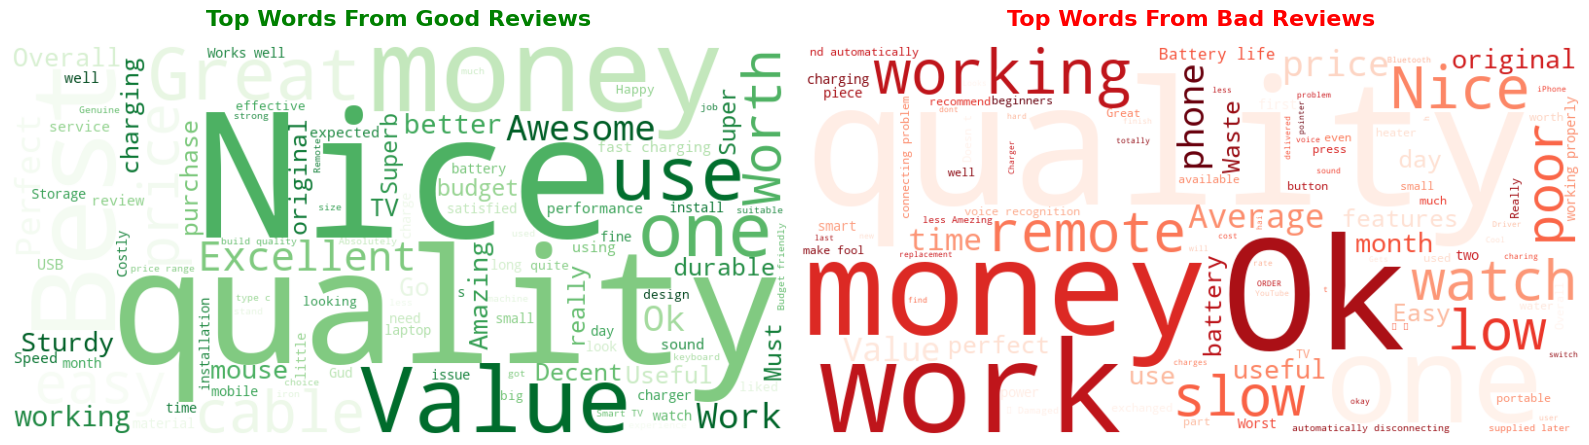

In [56]:
from wordcloud import WordCloud, STOPWORDS

#===============================================
#       DATA PREPRATION GOOD VS BAD REVIEWS
#===============================================

good_reviews = df[df['rating'] > 4.2]['review_title'].dropna().astype(str)
bad_reviews = df[df['rating'] < 3.5]['review_title'].dropna().astype(str)

# Combining all good reviews into a single string
text_good = " ".join(review for review in good_reviews)
text_bad = " ".join(review for review in bad_reviews)
# Defining the Stopwords to filter out cloud
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['product', 'amazon', 'buy', 'good', 'bad', 'item'])

#=====================================
#    DESIGNING THE  WORD CLOUDS
#=====================================
wordcloud_good = WordCloud(width = 800,
                            height = 400, background_color = 'white',
                              stopwords = custom_stopwords, colormap = 'Greens',
                              max_words = 100).generate(text_good)
wordcloud_bad = WordCloud(width = 800,
                           height = 400,background_color = 'white',
                           stopwords = custom_stopwords, colormap = 'Reds',
                           max_words = 100).generate(text_bad)

#=====================================
#     PLOTTING THE WORD CLOUDS
#=====================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8)) 
#PLOT GOOD REVIEWS
axes[0].imshow(wordcloud_good, interpolation = 'bilinear')
axes[0].set_title('Top Words From Good Reviews', fontsize = 16, fontweight = 'bold', color = 'green', pad = 15)
axes[0].axis('off')

#PLOT BAD REVIEWS
axes[1].imshow(wordcloud_bad, interpolation = 'bilinear')
axes[1].set_title('Top Words From Bad Reviews', fontsize = 16, fontweight = 'bold', color = 'red', pad = 15)
axes[1].axis('off')

plt.tight_layout()
plt.show()